In [4]:
import pandas as pd
import numpy as np

# Load the data from the Excel file
df = pd.read_excel("/content/DB_A6_G5.xlsx")

# Chỉ giữ các cột cần thiết từ DB_A6_G5
cols_needed = [
    "District", "Road Name", "Date", "Elevation (m)", "Rain_duration (hours)",
    "Factors", "Max_depth (cm)", "Rain_fall (mm)", "nasa_rain_mm",
    "Distance_to_Water_m", "Rain_24h_mm", "Rain_Intensity"
]

df = df[cols_needed].copy()

# Đổi tên cột cho dễ xử lý
df = df.rename(columns={
    "District": "District",
    "Road Name": "Road_Name",
    "Date": "Date",
    "Elevation (m)": "Elevation",
    "Rain_duration (hours)": "Rain_duration",
    "Factors": "Cause",
    "Max_depth (cm)": "Max_depth",
    "Rain_fall (mm)": "Rain_fall",
    "nasa_rain_mm": "NASA_rain_mm",
    "Distance_to_Water_m": "Distance_to_Water",
    "Rain_24h_mm": "Rain_24h_mm",
    "Rain_Intensity": "Rain_Intensity_cat"
})

# Chuyển kiểu dữ liệu
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

num_cols = ["Elevation", "Rain_duration", "Max_depth", "Rain_fall", "NASA_rain_mm", "Distance_to_Water", "Rain_24h_mm"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Tạo Rain_Intensity dạng số = lượng mưa / thời lượng
df["Rain_Intensity_num"] = df["Rain_fall"] / df["Rain_duration"]

# Xử lý vô cực và thiếu
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Loại bỏ dòng thiếu ở các biến chính
df_model = df.dropna(subset=["Max_depth", "Rain_fall", "Rain_duration", "Elevation", "Distance_to_Water"]).copy()

# Feature engineering
df_model["Intensity_x_Elevation"] = df_model["Rain_Intensity_num"] * df_model["Elevation"]

# Phân loại tháng/mùa đơn giản
df_model["Month"] = df_model["Date"].dt.month
df_model["Year"] = df_model["Date"].dt.year

print(df_model.shape)
df_model.head()

(305, 16)


,District,Road_Name,Date,Elevation,Rain_duration,Cause,Max_depth,Rain_fall,NASA_rain_mm,Distance_to_Water,Rain_24h_mm,Rain_Intensity_cat,Rain_Intensity_num,Intensity_x_Elevation,Month,Year
0,Cầu Giấy,Hoa Bằng,2022-05-29,12.92,2.0,Extreme rain,70.0,100.0,7.99,206.36,6.8,Low,50.0,646.0,5,2022
1,Cầu Giấy,Xuân Thủy,2022-08-12,8.26,5.0,Extreme rain,50.0,200.0,44.03,139.99,35.7,Medium,40.0,330.4,8,2022
2,Cầu Giấy,Chợ Nhà Xanh,2022-08-12,8.43,5.0,Extreme rain,50.0,200.0,44.03,79.86,35.7,Medium,40.0,337.2,8,2022
3,Cầu Giấy,Dương Đình Nghệ,2022-07-05,7.32,0.5,Extreme rain,20.0,130.0,23.29,260.58,18.1,Medium,260.0,1903.2,7,2022
4,Cầu Giấy,Xuân Thủy,2022-07-05,8.26,0.5,Extreme rain,35.0,130.0,23.29,139.99,18.1,Medium,260.0,2147.6,7,2022


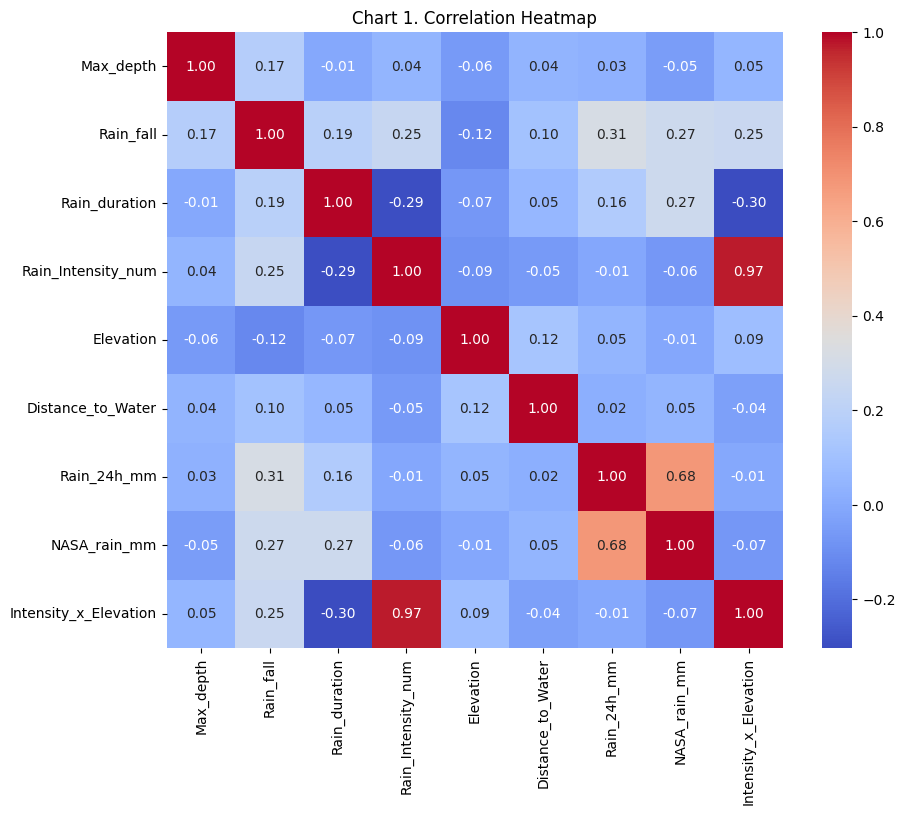

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = ["Max_depth", "Rain_fall", "Rain_duration", "Rain_Intensity_num", "Elevation", "Distance_to_Water", "Rain_24h_mm", "NASA_rain_mm", "Intensity_x_Elevation"]
corr_df = df_model[corr_cols].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Chart 1. Correlation Heatmap")
plt.savefig("01_correlation_heatmap.png")

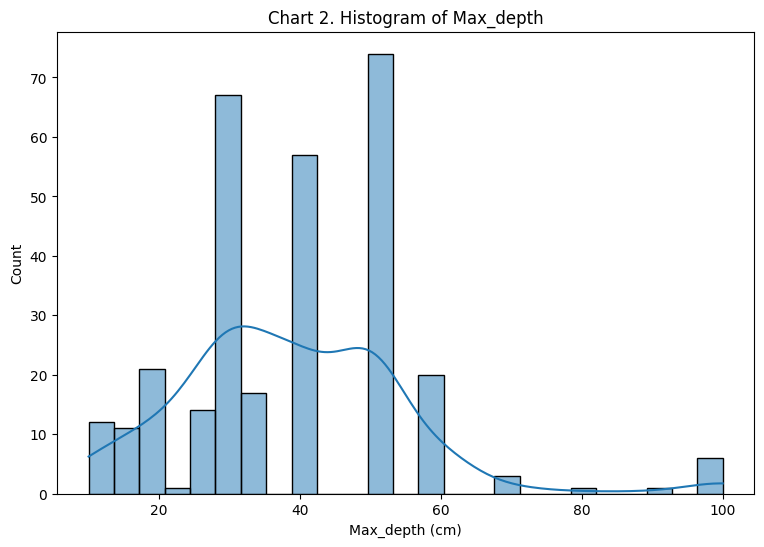

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
sns.histplot(df_model["Max_depth"], bins=25, kde=True)
plt.title("Chart 2. Histogram of Max_depth")
plt.xlabel("Max_depth (cm)")
plt.savefig("02_hist_target_max_depth")

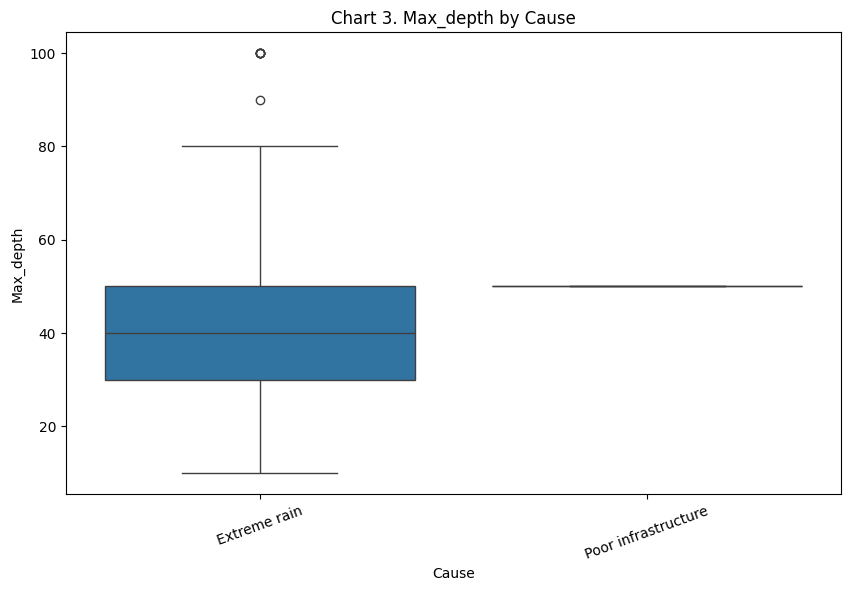

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
order = df_model.groupby("Cause")["Max_depth"].median().sort_values().index
sns.boxplot(data=df_model, x="Cause", y="Max_depth", order=order)
plt.title("Chart 3. Max_depth by Cause")
plt.xticks(rotation=20)
plt.savefig("03_boxplot_maxdepth_by_cause")

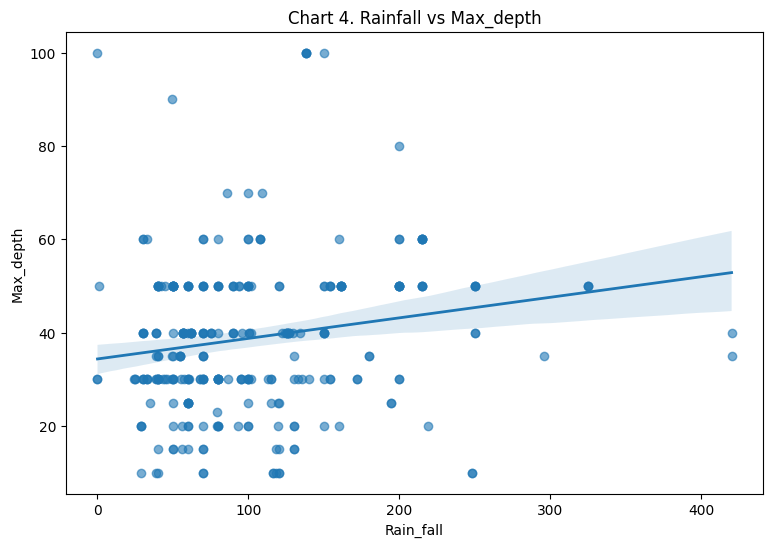

In [8]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df_model, x="Rain_fall", y="Max_depth", scatter_kws={"alpha":0.6}, line_kws={"linewidth":2})
plt.title("Chart 4. Rainfall vs Max_depth")
plt.savefig("04_scatter_rainfall_maxdepth")

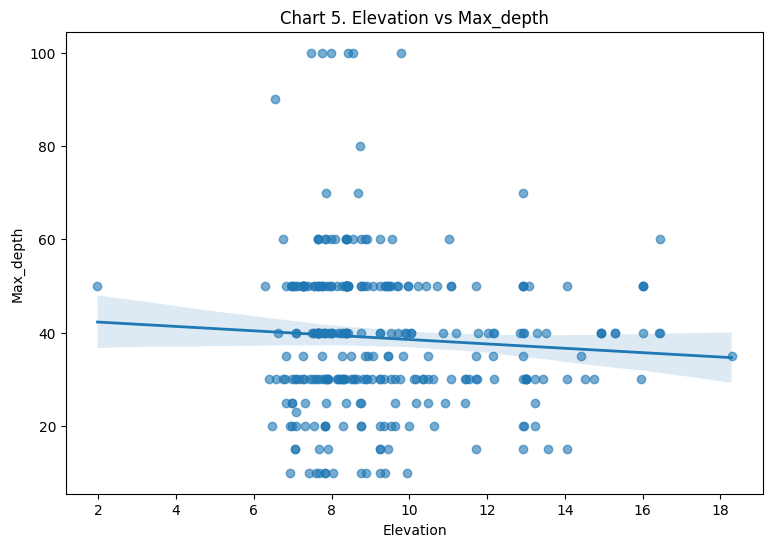

In [9]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df_model, x="Elevation", y="Max_depth", scatter_kws={"alpha":0.6}, line_kws={"linewidth":2})
plt.title("Chart 5. Elevation vs Max_depth")
plt.savefig("05_scatter_elevation_maxdepth")

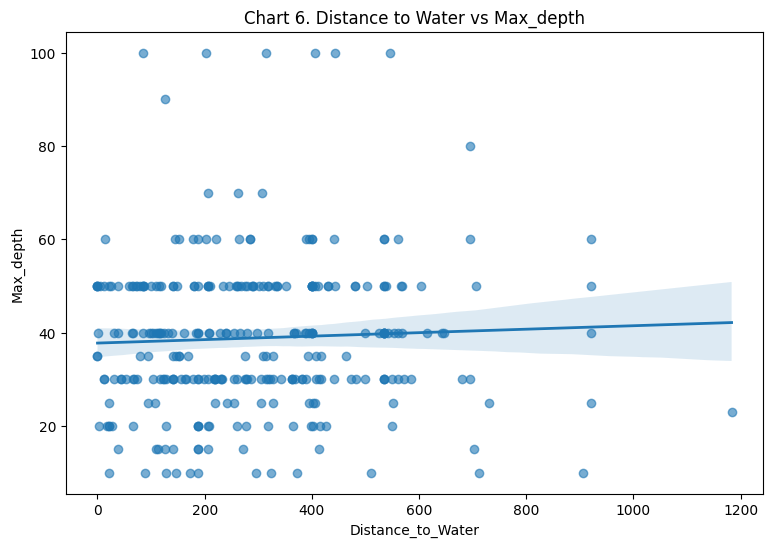

In [10]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df_model, x="Distance_to_Water", y="Max_depth", scatter_kws={"alpha":0.6}, line_kws={"linewidth":2})
plt.title("Chart 6. Distance to Water vs Max_depth")
plt.savefig("06_scatter_distance_maxdepth")

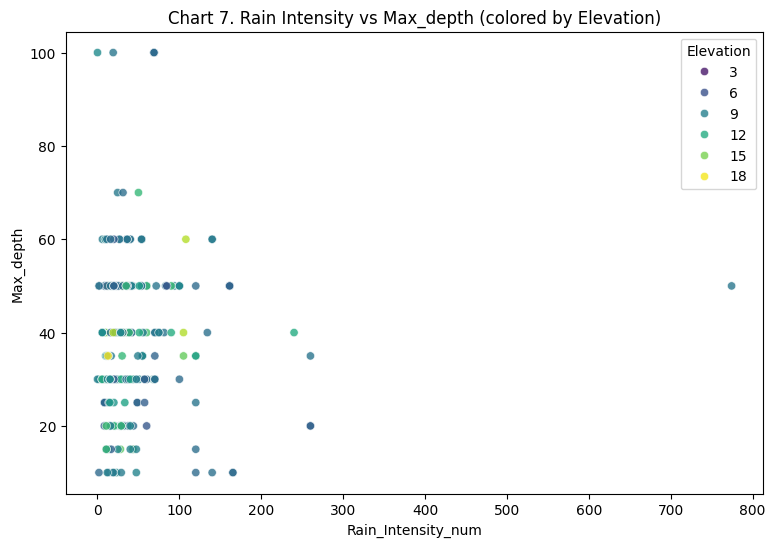

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_model,
    x="Rain_Intensity_num",
    y="Max_depth",
    hue="Elevation",
    palette="viridis",
    alpha=0.8
)
plt.title("Chart 7. Rain Intensity vs Max_depth (colored by Elevation)")
plt.savefig("07_interaction_color_elevation")

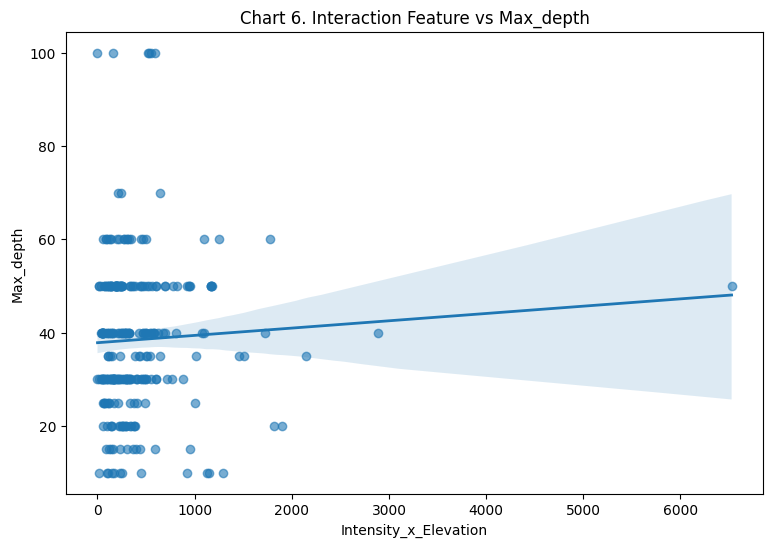

In [12]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df_model, x="Intensity_x_Elevation", y="Max_depth", scatter_kws={"alpha":0.6}, line_kws={"linewidth":2})
plt.title("Chart 6. Interaction Feature vs Max_depth")
plt.savefig("06_interaction_feature_vs_target")

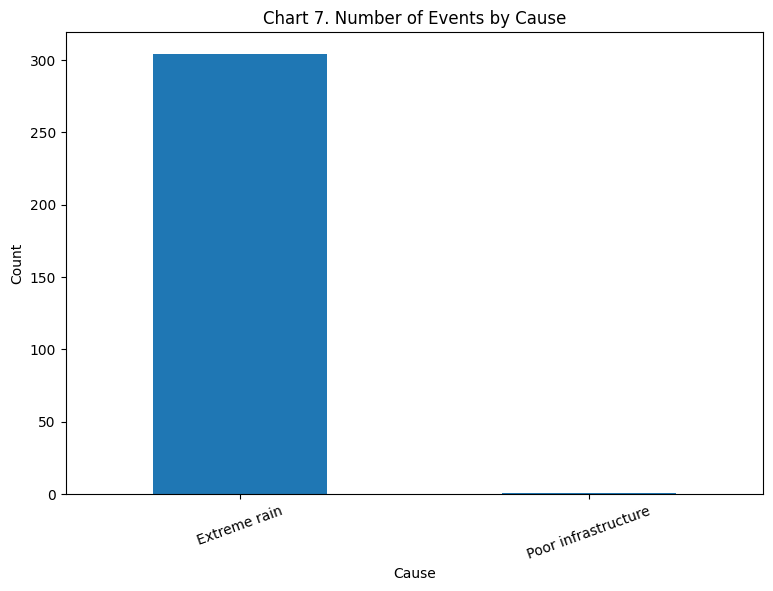

In [13]:
plt.figure(figsize=(9, 6))
df_model["Cause"].value_counts().plot(kind="bar")
plt.title("Chart 7. Number of Events by Cause")
plt.xlabel("Cause")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.savefig("07_cause_count")

In [14]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Dummy variables cho Cause
df_reg = pd.get_dummies(df_model, columns=["Cause"], drop_first=True)

# Model 1: basic OLS
model1_vars = ["Rain_fall", "Rain_Intensity_num", "Elevation", "Distance_to_Water"]
X1 = df_reg[model1_vars].dropna()
y1 = df_reg.loc[X1.index, "Max_depth"]

# Ensure X1 is purely numeric for statsmodels
X1 = X1.apply(pd.to_numeric, errors='coerce').dropna()
y1 = y1.loc[X1.index] # Realign y1 after dropping rows from X1

X1_const = sm.add_constant(X1)
model1 = sm.OLS(y1, X1_const).fit()

print(model1.summary())

# Model 2: advanced OLS
cause_dummy_cols = [c for c in df_reg.columns if c.startswith("Cause_")]
model2_vars = ["Rain_fall", "Rain_Intensity_num", "Elevation", "Distance_to_Water", "Intensity_x_Elevation"] + cause_dummy_cols

X2 = df_reg[model2_vars].dropna()
y2 = df_reg.loc[X2.index, "Max_depth"]

# Ensure X2 is purely numeric for statsmodels, and explicitly cast to float
X2 = X2.apply(pd.to_numeric, errors='coerce').dropna().astype(float)
y2 = y2.loc[X2.index] # Realign y2 after dropping rows from X2

X2_const = sm.add_constant(X2)
model2 = sm.OLS(y2, X2_const).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              Max_depth   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.377
Date:                Fri, 20 Mar 2026   Prob (F-statistic):             0.0522
Time:                        12:35:48   Log-Likelihood:                -1199.9
No. Observations:                 287   AIC:                             2410.
Df Residuals:                     282   BIC:                             2428.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 36.3124      4

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


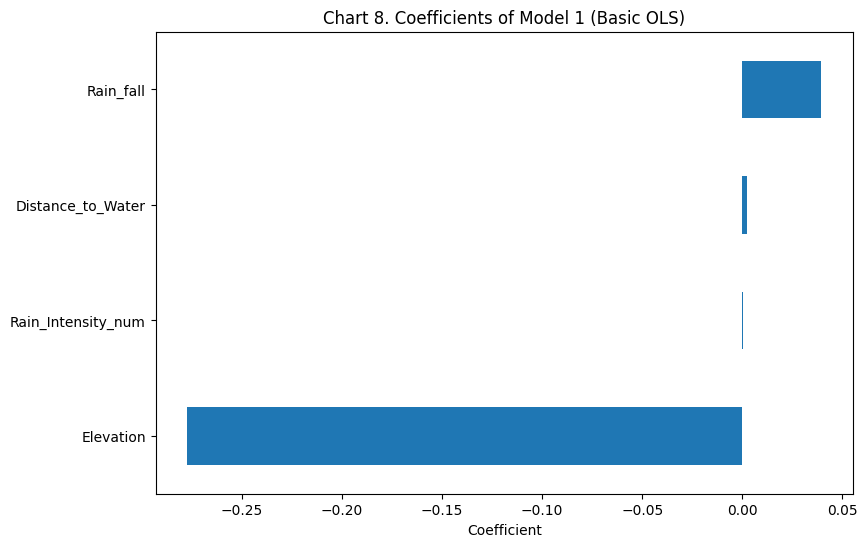

In [15]:
coef1 = model1.params.drop("const").sort_values()

plt.figure(figsize=(9, 6))
coef1.plot(kind="barh")
plt.title("Chart 8. Coefficients of Model 1 (Basic OLS)")
plt.xlabel("Coefficient")
plt.savefig("8_model1_coefficients")

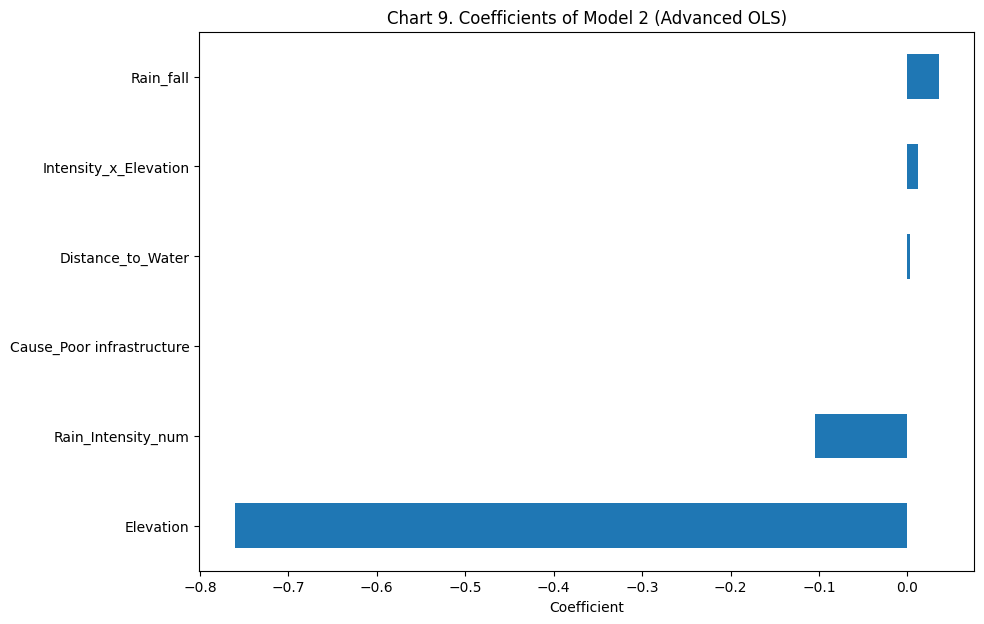

In [16]:
coef2 = model2.params.drop("const").sort_values()

plt.figure(figsize=(10, 7))
coef2.plot(kind="barh")
plt.title("Chart 9. Coefficients of Model 2 (Advanced OLS)")
plt.xlabel("Coefficient")
plt.savefig("9_model2_coefficients")

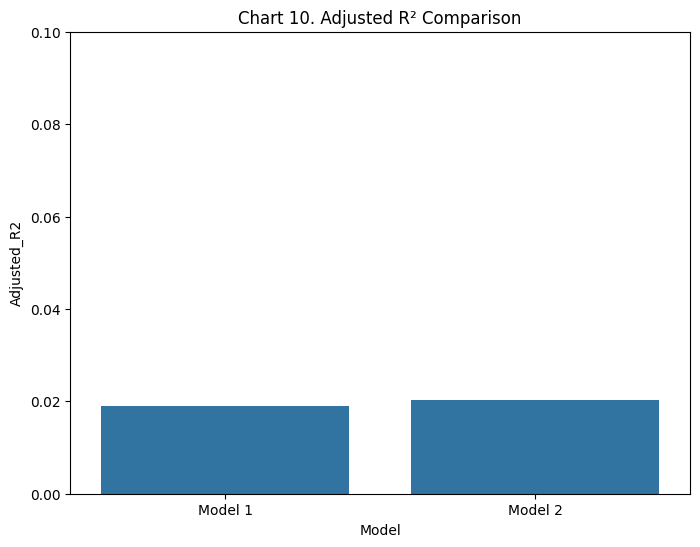

In [17]:
compare_df = pd.DataFrame({
    "Model": ["Model 1", "Model 2"],
    "Adjusted_R2": [model1.rsquared_adj, model2.rsquared_adj]
})

plt.figure(figsize=(8, 6))
sns.barplot(data=compare_df, x="Model", y="Adjusted_R2")
plt.title("Chart 10. Adjusted R² Comparison")
plt.ylim(0, max(compare_df["Adjusted_R2"].max() * 1.2, 0.1))
plt.savefig("10_adjusted_r2_comparison")

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Tính sai số cho Model 1 (Basic OLS)
y1_pred = model1.predict(X1_const)
rmse1 = np.sqrt(mean_squared_error(y1, y1_pred))
mae1 = mean_absolute_error(y1, y1_pred)

# 2. Tính sai số cho Model 2 (Advanced OLS)
y2_pred = model2.predict(X2_const)
rmse2 = np.sqrt(mean_squared_error(y2, y2_pred))
mae2 = mean_absolute_error(y2, y2_pred)

# 3. In kết quả ra màn hình
print("--- CHỈ SỐ SAI SỐ TUYỆT ĐỐI ---")
print(f"Model 1 - RMSE: {rmse1:.2f} cm | MAE: {mae1:.2f} cm")
print(f"Model 2 - RMSE: {rmse2:.2f} cm | MAE: {mae2:.2f} cm")

--- CHỈ SỐ SAI SỐ TUYỆT ĐỐI ---
Model 1 - RMSE: 15.83 cm | MAE: 11.95 cm
Model 2 - RMSE: 15.79 cm | MAE: 11.95 cm


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Variable"] = X2_const.columns
vif_df["VIF"] = [variance_inflation_factor(X2_const.values, i) for i in range(X2_const.shape[1])]
vif_df = vif_df[vif_df["Variable"] != "const"].sort_values("VIF", ascending=False)
vif_df

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variable,VIF
5,Intensity_x_Elevation,34.494555
2,Rain_Intensity_num,33.897931
3,Elevation,2.118230
1,Rain_fall,1.142159
4,Distance_to_Water,1.037680
6,Cause_Poor infrastructure,NaN


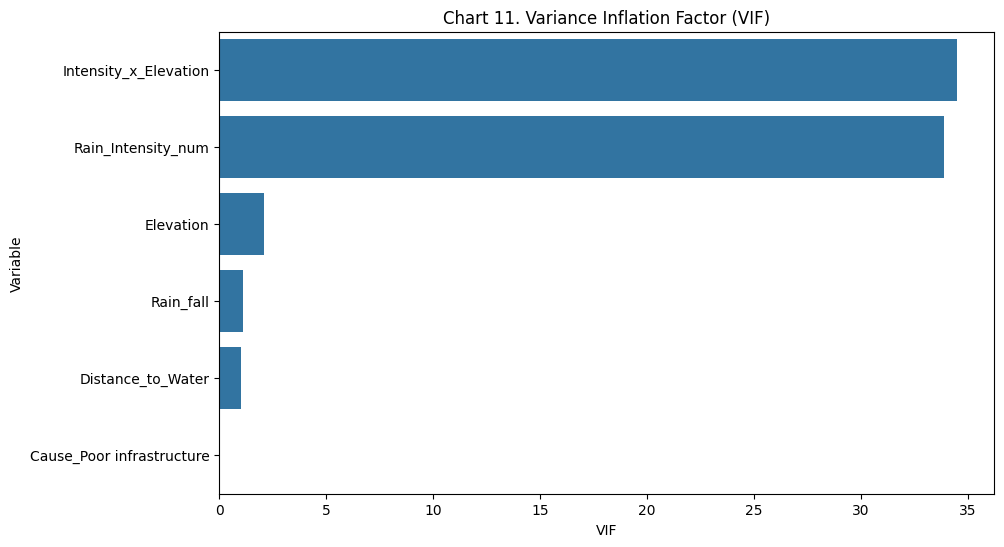

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=vif_df, x="VIF", y="Variable")
plt.title("Chart 11. Variance Inflation Factor (VIF)")
plt.savefig("11_vif_plot")

<Figure size 700x700 with 0 Axes>

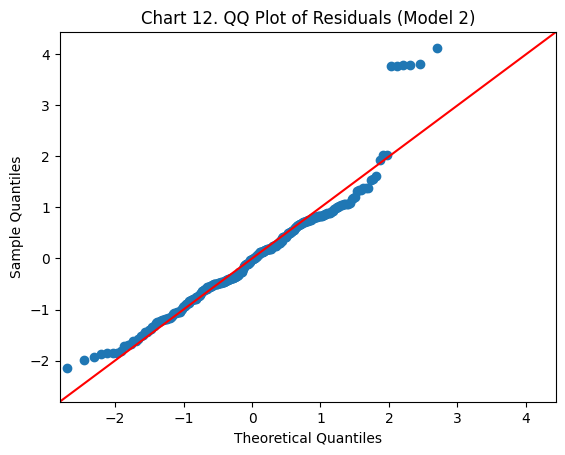

In [21]:
plt.figure(figsize=(7, 7))
sm.qqplot(model2.resid, line="45", fit=True)
plt.title("Chart 12. QQ Plot of Residuals (Model 2)")
plt.savefig("12_qqplot_residuals")

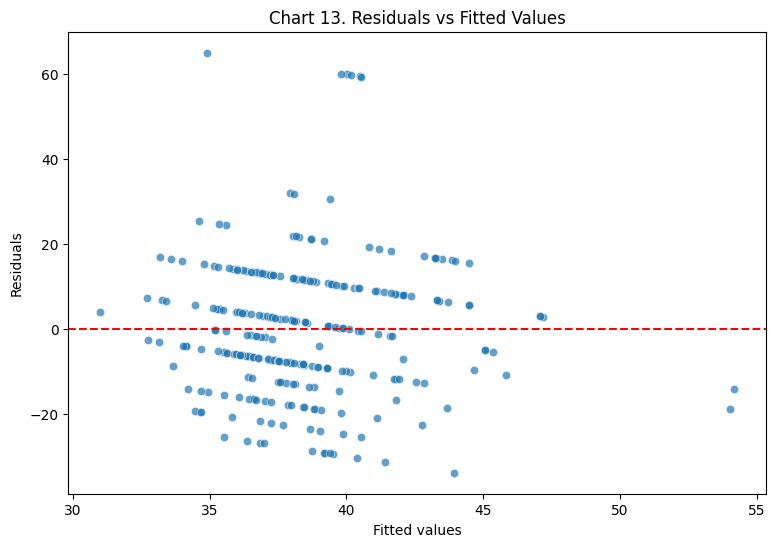

In [22]:
fitted_vals = model2.fittedvalues
residuals = model2.resid

plt.figure(figsize=(9, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Chart 13. Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.savefig("13_residuals_vs_fitted")

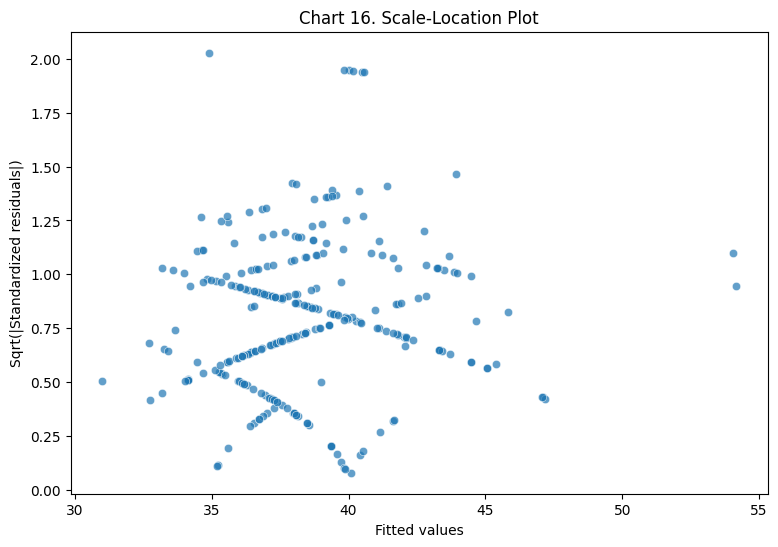

In [23]:
std_resid = np.sqrt(np.abs((residuals - residuals.mean()) / residuals.std()))

plt.figure(figsize=(9, 6))
sns.scatterplot(x=fitted_vals, y=std_resid, alpha=0.7)
plt.title("Chart 16. Scale-Location Plot")
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized residuals|)")
plt.savefig("16_scale_location")

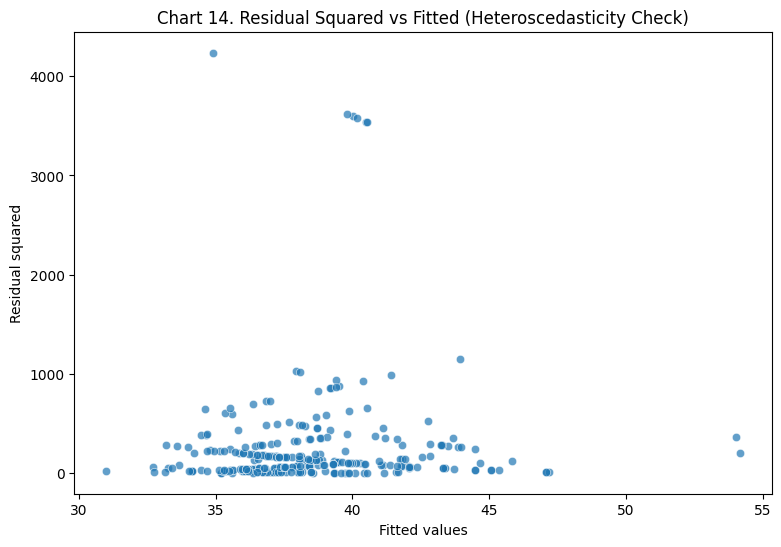

In [24]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=fitted_vals, y=residuals**2, alpha=0.7)
plt.title("Chart 14. Residual Squared vs Fitted (Heteroscedasticity Check)")
plt.xlabel("Fitted values")
plt.ylabel("Residual squared")
plt.savefig("14_residual_squared_vs_fitted")

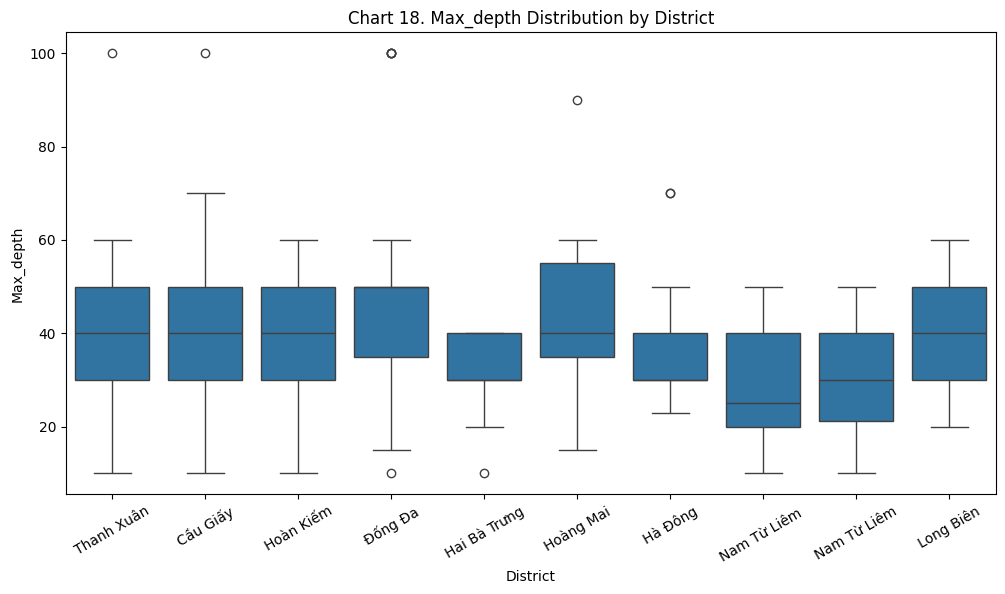

In [25]:
top_districts = df_model["District"].value_counts().head(10).index
plot_df = df_model[df_model["District"].isin(top_districts)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x="District", y="Max_depth", order=top_districts)
plt.title("Chart 18. Max_depth Distribution by District")
plt.xticks(rotation=30)
plt.savefig("18_boxplot_district")

Available sheet names: ['Cube_1_RollUp', 'Cube_2_Spatial', 'Cube_3_DrillDown', 'Cube_4_Slice', 'Cube_5_Dice', 'Cube_6_Correlation']


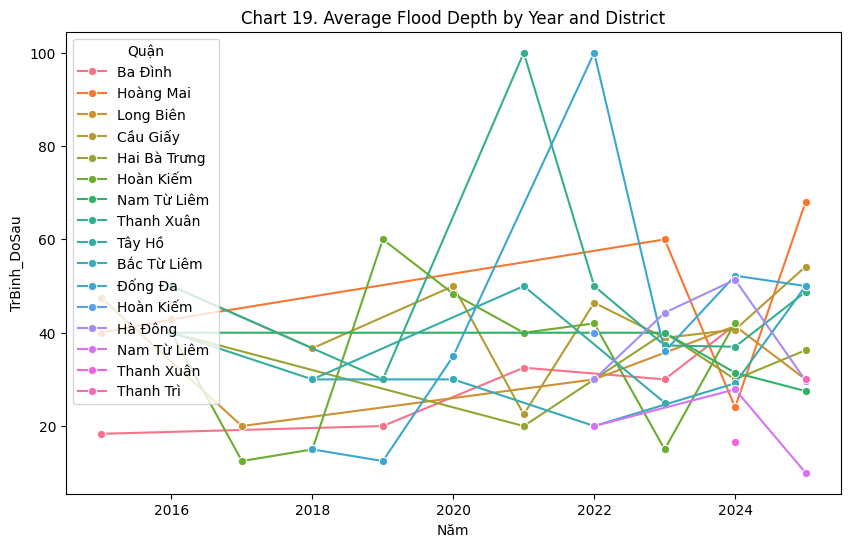

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Try to identify sheet names in the Excel file
xls = pd.ExcelFile('/content/DB_A6_G5_Cubes.xlsx')
print("Available sheet names:", xls.sheet_names)

# Once you know the correct sheet name, replace 'Sheet1' with it.
# For example, if the correct sheet name is 'DataSheet', change the line below to:
# cube1 = pd.read_excel('/content/DB_A6_G5_Cubes.xlsx', sheet_name='DataSheet')
cube1 = pd.read_excel('/content/DB_A6_G5_Cubes.xlsx', sheet_name='Cube_1_RollUp') # Placeholder, needs correction

# Rename columns to match the plotting code
cube1 = cube1.rename(columns={
    'Year': 'Năm',
    'District': 'Quận',
    'Avg_Max_Depth': 'TrBinh_DoSau'
})

plt.figure(figsize=(10, 6))
sns.lineplot(data=cube1, x="Năm", y="TrBinh_DoSau", hue="Quận", marker="o")
plt.title("Chart 19. Average Flood Depth by Year and District")
plt.savefig("19_cube_rollup_line")

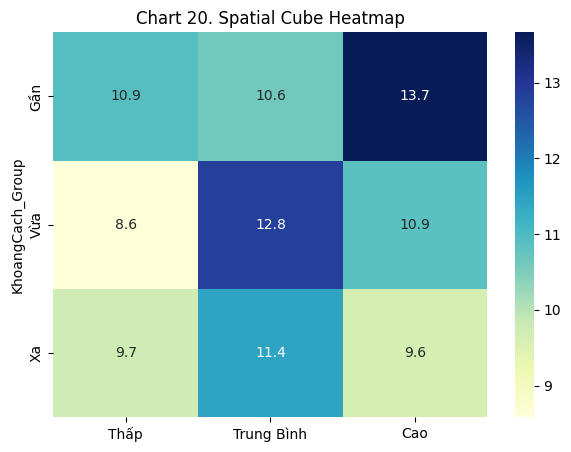

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cube2 = pd.read_excel('/content/DB_A6_G5_Cubes.xlsx', sheet_name='Cube_2_Spatial')

cube2_plot = cube2.set_index("KhoangCach_Group")

plt.figure(figsize=(7, 5))
sns.heatmap(cube2_plot, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Chart 20. Spatial Cube Heatmap")
plt.savefig("20_cube_spatial_heatmap")

<Figure size 800x500 with 0 Axes>

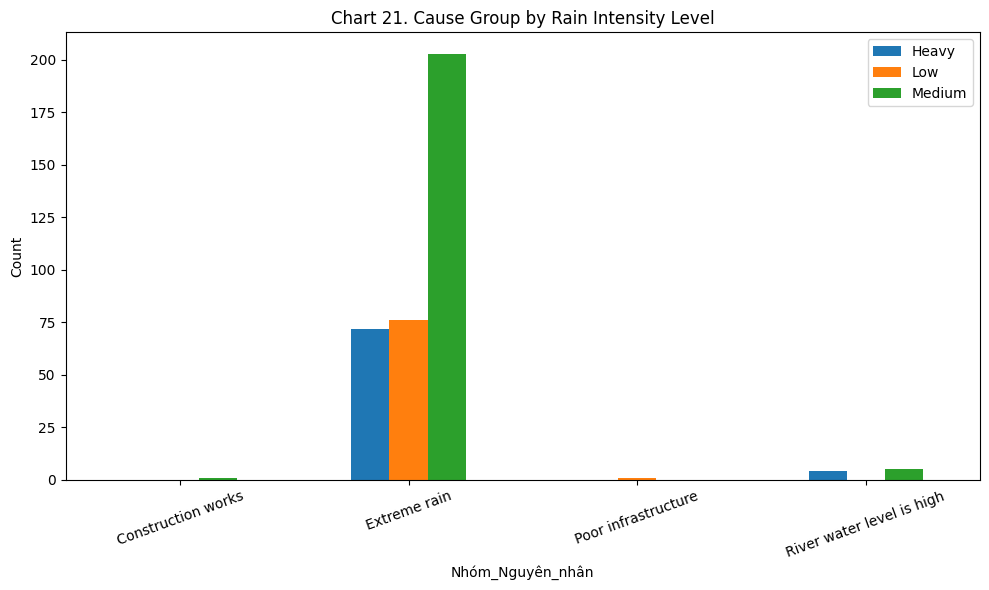

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cube3 = pd.read_excel('/content/DB_A6_G5_Cubes.xlsx', sheet_name='Cube_3_DrillDown')

cube3_plot = cube3.set_index("Nhóm_Nguyên_nhân")

plt.figure(figsize=(8, 5))
cube3_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Chart 21. Cause Group by Rain Intensity Level")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("21_cube_drilldown_bar.png", dpi=300, bbox_inches="tight")
plt.show()

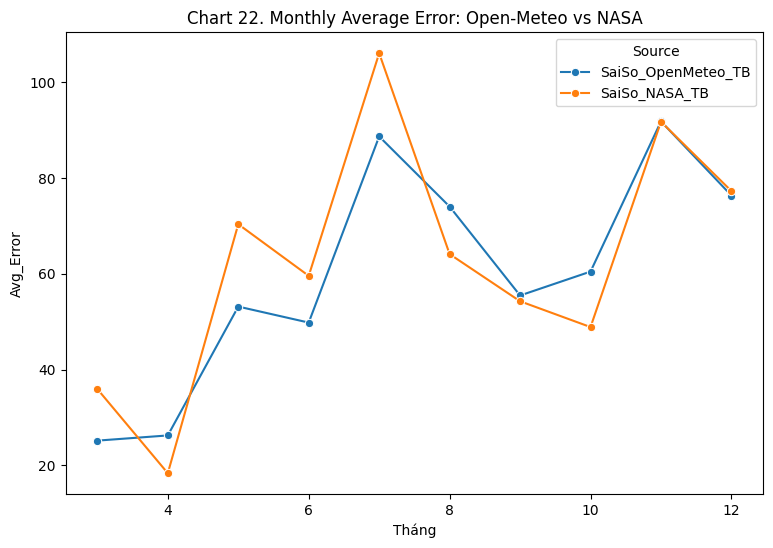

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cube5 = pd.read_excel('/content/DB_A6_G5_Cubes.xlsx', sheet_name='Cube_5_Dice')

cube5_long = cube5.melt(id_vars="Tháng", var_name="Source", value_name="Avg_Error")

plt.figure(figsize=(9, 6))
sns.lineplot(data=cube5_long, x="Tháng", y="Avg_Error", hue="Source", marker="o")
plt.title("Chart 22. Monthly Average Error: Open-Meteo vs NASA")
plt.savefig("22_cube_error_comparison")

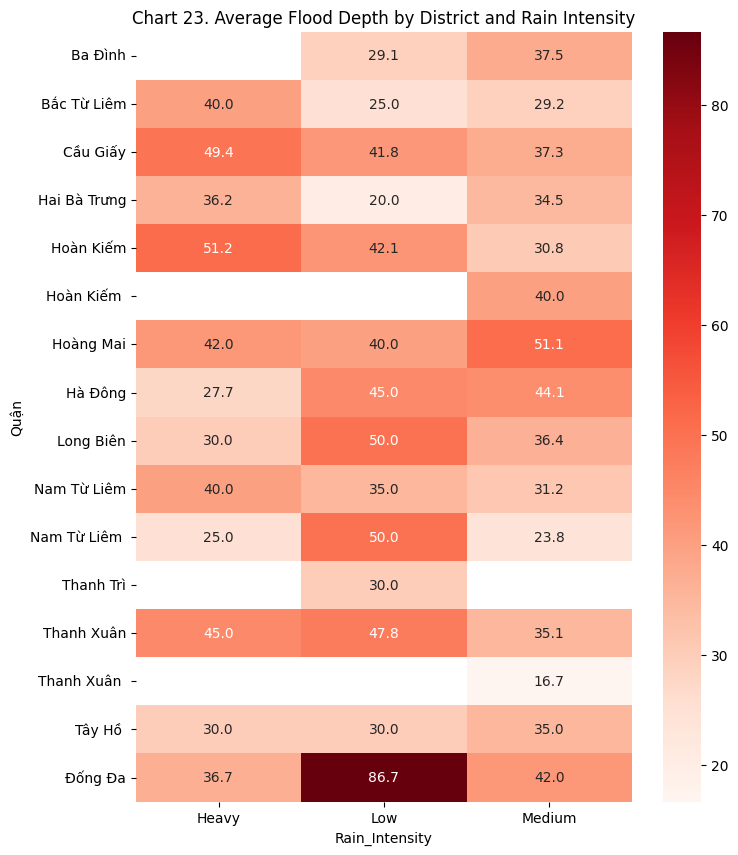

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cube6 = pd.read_excel('/content/DB_A6_G5_Cubes.xlsx', sheet_name='Cube_6_Correlation')
pivot6 = cube6.pivot(index="Quận", columns="Rain_Intensity", values="TrBinh_DoNgap")

plt.figure(figsize=(8, 10))
sns.heatmap(pivot6, annot=True, cmap="Reds", fmt=".1f")
plt.title("Chart 23. Average Flood Depth by District and Rain Intensity")
plt.savefig("23_cube_correlation_heatmap")

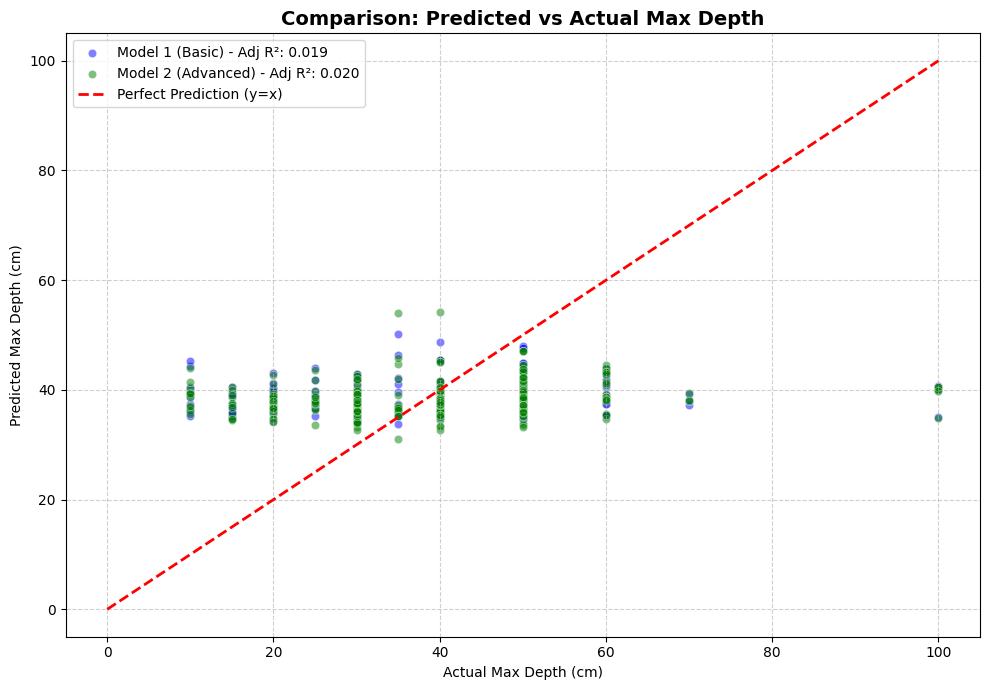

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Lấy giá trị thực tế và dự báo từ 2 model
y_actual = y2 # Cả 2 model dùng chung tập y (sau khi align)
y_pred1 = model1.predict(X1_const)
y_pred2 = model2.predict(X2_const)

plt.figure(figsize=(10, 7))

# Vẽ Model 1
sns.scatterplot(x=y_actual, y=y_pred1, alpha=0.5, label=f'Model 1 (Basic) - Adj R²: {model1.rsquared_adj:.3f}', color='blue')

# Vẽ Model 2
sns.scatterplot(x=y_actual, y=y_pred2, alpha=0.5, label=f'Model 2 (Advanced) - Adj R²: {model2.rsquared_adj:.3f}', color='green')

# Đường 45 độ (lý tưởng)
max_val = max(y_actual.max(), y_pred1.max(), y_pred2.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')

plt.title("Comparison: Predicted vs Actual Max Depth", fontsize=14, fontweight='bold')
plt.xlabel("Actual Max Depth (cm)")
plt.ylabel("Predicted Max Depth (cm)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("model_prediction_comparison.png")
plt.show()